# F1 Tyre Degradation and Pit Strategy (AP in Part B)

This notebook is split into:

- **Part A:** estimate tyre degradation rates, fuel/track gain, and pit-stop loss directly from FastF1 data (without AP fitting)
- **Part B:** use the extracted rates in an AP model to compare and optimize pit strategies

In [22]:
# If needed, run once:
# !pip install fastf1 scipy pandas numpy matplotlib

import fastf1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from itertools import product
from typing import cast

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)

In [23]:
import os
os.makedirs('fastf1_cache', exist_ok=True)
fastf1.Cache.enable_cache('fastf1_cache')

## Part A) Extract degradation rates and pit loss from data

In [30]:
# ---------- Inputs ----------
YEAR = 2021
GRAND_PRIX = 'France'
SESSION = 'R'

COMPOUNDS_TO_ANALYZE = ['SOFT', 'MEDIUM', 'HARD']

In [31]:
session = fastf1.get_session(YEAR, GRAND_PRIX, SESSION)
session.load()

all_laps = session.laps.copy()

core           INFO 	Loading data for French Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 33 completed the race distance 00:00.047000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           I

In [26]:
display(all_laps[all_laps['IsAccurate'].fillna(True)][['Driver', 'LapNumber', 'Stint', 'Compound', 'LapTime', 'PitInTime', 'PitOutTime', 'IsAccurate']].head())

,Driver,LapNumber,Stint,Compound,LapTime,PitInTime,PitOutTime,IsAccurate
1,NOR,2.0,1.0,MEDIUM,0 days 00:01:38.480000,NaT,NaT,True
2,NOR,3.0,1.0,MEDIUM,0 days 00:01:38.406000,NaT,NaT,True
3,NOR,4.0,1.0,MEDIUM,0 days 00:01:38.446000,NaT,NaT,True
4,NOR,5.0,1.0,MEDIUM,0 days 00:01:37.938000,NaT,NaT,True
5,NOR,6.0,1.0,MEDIUM,0 days 00:01:37.843000,NaT,NaT,True


In [ ]:
def prepare_nonpit_laps(laps_df: pd.DataFrame, group_cols: list):
    laps = laps_df.copy()
    laps = laps[laps['LapTime'].notna()].copy()
    
    # filter accurate laps if the column exists, otherwise keep all non-NaN laps
    # should already filter out SC/VSC laps
    if 'IsAccurate' in laps.columns:
        laps = laps[laps['IsAccurate'].fillna(True)].copy()
    
    laps['CompoundU'] = laps['Compound'].str.upper()
    laps['LapTimeSec'] = laps['LapTime'].dt.total_seconds()

    # Remove in/out laps and SC/VSC laps for clean pace deltas.
    laps = laps[laps['PitInTime'].isna() & laps['PitOutTime'].isna()].copy()
    # laps = remove_sc_vsc_laps(laps)
    # laps = laps.pick_quicklaps(threshold=1.07)

    laps = laps.sort_values(group_cols + ['LapNumber']).copy()
    laps['TyreLap'] = laps.groupby(group_cols).cumcount() + 1
    laps['LapDeltaSec'] = laps.groupby(group_cols)['LapTimeSec'].diff()

    return laps


def estimate_fuel_track_gain_from_field(session_laps, frontier_quantile=0.2):
    field_nonpit = prepare_nonpit_laps(session_laps, group_cols=['Driver', 'Stint'])
    frontier = field_nonpit.groupby('LapNumber')['LapTimeSec'].quantile(frontier_quantile).dropna().sort_index()
    deltas = frontier.diff().dropna()
    if len(deltas) < 5:
        raise ValueError('Not enough field-lap deltas to estimate fuel/track gain.')
    return float(np.median(deltas))


# def theil_sen_slope(x, y):
#     x = np.asarray(x, dtype=float)
#     y = np.asarray(y, dtype=float)
#     slopes = []
#     n = len(x)
#     for i in range(n):
#         for j in range(i + 1, n):
#             dx = x[j] - x[i]
#             if dx != 0:
#                 slopes.append((y[j] - y[i]) / dx)
#     if not slopes:
#         return np.nan
#     return float(np.median(slopes))

def theil_sen_slope(x, y):
		if len(x) < 2:
				return np.nan
		slope, _, _, _ = scipy.stats.theilslopes(y, x)
		return float(slope)


def estimate_overall_deg_rates(nonpit_laps, compounds, fuel_track_gain):
    raw_deg = {}
    used_deg = {}
    observed_delta = {}
    ts_deg = {}
    q70_delta = {}

    for c in compounds:
        tmp = nonpit_laps[nonpit_laps['CompoundU'] == c].copy()
        if len(tmp) < 8:
            continue

        # Remove race trend first, then estimate tyre-age effect robustly.
        tmp['AdjLapTime'] = tmp['LapTimeSec'] - fuel_track_gain * (tmp['LapNumber'] - 1)
        q1, q3 = np.quantile(tmp['AdjLapTime'], [0.25, 0.75])
        iqr = q3 - q1
        low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        tmp = tmp[(tmp['AdjLapTime'] >= low) & (tmp['AdjLapTime'] <= high)]
        if len(tmp) < 6:
            continue

        # Primary estimate: Theil-Sen slope of adjusted lap time vs tyre age.
        d_ts = theil_sen_slope(tmp['TyreLap'].to_numpy(), tmp['AdjLapTime'].to_numpy())

        # Fallback/support estimate: upper-quantile adjusted lap deltas.
        group_cols = ['Driver', 'Stint'] if 'Driver' in tmp.columns else ['Stint']
        tmp = tmp.sort_values(group_cols + ['LapNumber']).copy()
        tmp['AdjLapDelta'] = tmp.groupby(group_cols)['AdjLapTime'].diff()
        deltas = tmp['AdjLapDelta'].dropna()
        if len(deltas) >= 4:
            d_q70 = float(np.quantile(deltas, 0.70))
        else:
            d_q70 = float(d_ts) if not np.isnan(d_ts) else 0.0

        # Hybrid to avoid systematic zeroing while keeping robustness.
        d_raw = max(float(d_ts) if not np.isnan(d_ts) else 0.0, 0.5 * max(d_q70, 0.0))
        d_used = max(d_raw, 0.0)

        observed_delta[c] = float(np.median(tmp['LapDeltaSec'].dropna()))
        ts_deg[c] = float(d_ts) if not np.isnan(d_ts) else 0.0
        q70_delta[c] = float(d_q70)
        raw_deg[c] = float(d_raw)
        used_deg[c] = float(d_used)

    return raw_deg, used_deg, observed_delta, ts_deg, q70_delta


def estimate_base_lap_times(nonpit_laps, compounds):
    base = {}
    for c in compounds:
        dfc = nonpit_laps[nonpit_laps['CompoundU'] == c].copy()
        if dfc.empty:
            continue
        first_laps = dfc[dfc['TyreLap'] == 1]['LapTimeSec']
        if first_laps.empty:
            first_laps = dfc[dfc['TyreLap'] <= 2]['LapTimeSec']
        if first_laps.empty:
            first_laps = dfc['LapTimeSec']
        base[c] = float(first_laps.median())
    return base


def estimate_pit_loss_from_local_baseline(laps_df, window=4):
    laps = laps_df.copy()
    laps = laps[laps['LapTime'].notna()].copy()
    laps['LapTimeSec'] = laps['LapTime'].dt.total_seconds()

    losses = []
    details = []

    for driver, dlaps in laps.groupby('Driver'):
        dlaps = dlaps.sort_values('LapNumber').copy()
        for row in dlaps[dlaps['PitInTime'].notna()].itertuples(index=False):
            in_lap = int(row.LapNumber)
            out_lap = in_lap + 1
            out_rows = dlaps[dlaps['LapNumber'] == out_lap]
            if out_rows.empty:
                continue
            out_row = out_rows.iloc[0]

            pre_window = dlaps[
                (dlaps['LapNumber'] >= in_lap - window)
                & (dlaps['LapNumber'] <= in_lap - 1)
                & dlaps['PitInTime'].isna()
                & dlaps['PitOutTime'].isna()
            ]

            post_window = dlaps[
                (dlaps['LapNumber'] >= out_lap + 1)
                & (dlaps['LapNumber'] <= out_lap + window)
                & dlaps['PitInTime'].isna()
                & dlaps['PitOutTime'].isna()
            ]

            if pre_window.empty or post_window.empty:
                continue

            expected_pair = float(pre_window['LapTimeSec'].median() + post_window['LapTimeSec'].median())
            actual_pair = float(row.LapTimeSec + out_row['LapTimeSec'])
            loss = actual_pair - expected_pair

            if loss > 0:
                losses.append(loss)
                details.append({
                    'Driver': driver,
                    'pit_in_lap': in_lap,
                    'pit_out_lap': out_lap,
                    'pit_loss_seconds': loss
                })

    if not losses:
        raise ValueError('Could not estimate pit loss from local baseline windows.')

    return float(np.median(losses)), pd.DataFrame(details)


overall_nonpit = prepare_nonpit_laps(all_laps, group_cols=['Driver', 'Stint'])
overall_nonpit = overall_nonpit[overall_nonpit['CompoundU'].isin(COMPOUNDS_TO_ANALYZE)].copy()
if overall_nonpit.empty:
    raise ValueError('No clean non-pit laps after filtering. Try another race/driver.')

fuel_track_gain_sec_per_lap = estimate_fuel_track_gain_from_field(session.laps)
raw_deg_by_compound, deg_rate_by_compound, observed_delta_by_compound, ts_deg_by_compound, q70_deg_by_compound = estimate_overall_deg_rates(
    overall_nonpit,
    compounds=COMPOUNDS_TO_ANALYZE,
    fuel_track_gain=fuel_track_gain_sec_per_lap
)
if not deg_rate_by_compound:
    raise ValueError('Could not estimate degradation rates for selected compounds.')

base_lap_by_compound = estimate_base_lap_times(overall_nonpit, list(deg_rate_by_compound.keys()))
PIT_STOP_LOSS_SECONDS, pit_loss_events_df = estimate_pit_loss_from_local_baseline(all_laps)

clean_laps_by_compound = {
    c: overall_nonpit[overall_nonpit['CompoundU'] == c].copy()
    for c in deg_rate_by_compound.keys()
}

model_inputs = {
    'deg_rate_by_compound': deg_rate_by_compound,
    'pit_stop_loss_seconds': PIT_STOP_LOSS_SECONDS,
    'fuel_track_gain_sec_per_lap': fuel_track_gain_sec_per_lap
}

print('model_inputs =')
print(model_inputs)
display(pit_loss_events_df.head())

summary_df = pd.DataFrame({
    'compound': list(deg_rate_by_compound.keys()),
    'observed_median_lap_delta_sec': [observed_delta_by_compound[c] for c in deg_rate_by_compound],
    'theil_sen_deg_sec_per_lap': [ts_deg_by_compound[c] for c in deg_rate_by_compound],
    'q70_adj_delta_sec_per_lap': [q70_deg_by_compound[c] for c in deg_rate_by_compound],
    'raw_estimated_deg_sec_per_lap': [raw_deg_by_compound[c] for c in deg_rate_by_compound],
    'strategy_deg_used_sec_per_lap': [deg_rate_by_compound[c] for c in deg_rate_by_compound],
    'decomposition_check_d_plus_gain': [deg_rate_by_compound[c] + fuel_track_gain_sec_per_lap for c in deg_rate_by_compound],
    'T0_for_partB_sec': [base_lap_by_compound[c] for c in deg_rate_by_compound]
}).sort_values('compound')
display(summary_df)

model_inputs =
{'deg_rate_by_compound': {'SOFT': 0.07739999999999438, 'MEDIUM': 0.13324999999999665, 'HARD': 0.10709999999999402}, 'pit_stop_loss_seconds': 23.390249999999995, 'fuel_track_gain_sec_per_lap': -0.029999999999986926}


,Driver,pit_in_lap,pit_out_lap,pit_loss_seconds
0,ALO,18,19,22.7755
1,BOT,17,18,22.4920
2,GAS,17,18,22.4740
3,GIO,28,29,23.1280
4,HAM,19,20,23.7155


,compound,observed_median_lap_delta_sec,theil_sen_deg_sec_per_lap,q70_adj_delta_sec_per_lap,raw_estimated_deg_sec_per_lap,strategy_deg_used_sec_per_lap,decomposition_check_d_plus_gain,T0_for_partB_sec
2,HARD,-0.031,0.0040,0.2142,0.10710,0.10710,0.07710,99.3405
1,MEDIUM,-0.054,0.0242,0.2665,0.13325,0.13325,0.10325,100.6120
0,SOFT,0.009,0.0080,0.1548,0.07740,0.07740,0.04740,99.1320


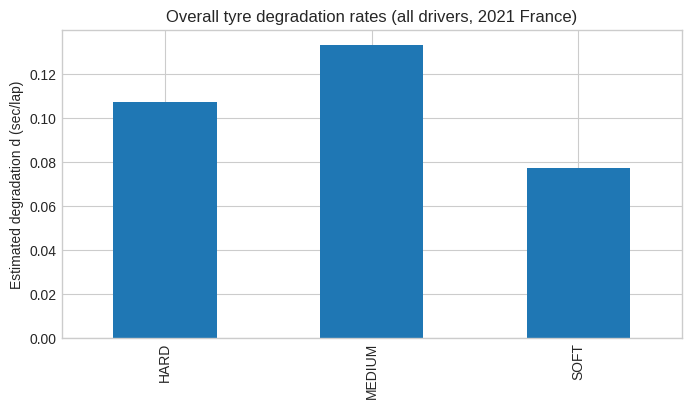

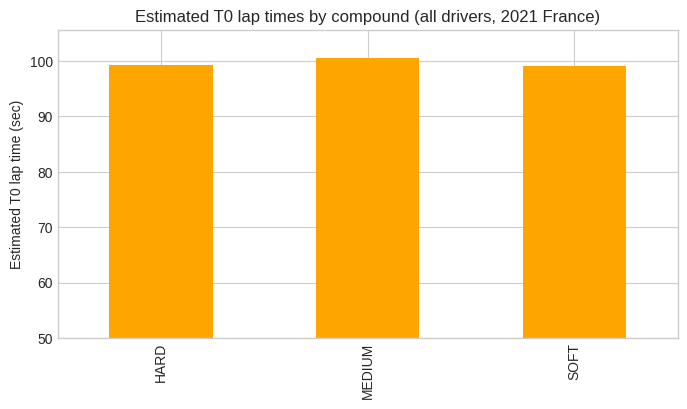

In [33]:
plt.figure(figsize=(8, 4))
pd.Series(deg_rate_by_compound).sort_index().plot(kind='bar')
plt.ylabel('Estimated degradation d (sec/lap)')
plt.title(f'Overall tyre degradation rates (all drivers, {YEAR} {GRAND_PRIX})')
plt.show()

# show T0 times for each compound
plt.figure(figsize=(8, 4))
pd.Series(base_lap_by_compound).sort_index().plot(kind='bar', color='orange')
plt.ylabel('Estimated T0 lap time (sec)')
plt.title(f'Estimated T0 lap times by compound (all drivers, {YEAR} {GRAND_PRIX})')
plt.ylim(50)
plt.show()

## Part B) AP model to find optimal pitting strategies

Use the extracted values from Part A in:

$$T_n = T_0 + (n-1)d$$

In [34]:
# import math

TOTAL_LAPS = int(all_laps['LapNumber'].max())

# Strategy search settings
MAX_STOPS = 3
MIN_STINT_LAPS = 8
REQUIRE_TWO_COMPOUNDS = True

available_compounds = list(deg_rate_by_compound.keys())

def stint_time_ap(t0, d, n_laps):
    # Sum_{n=1..N} [T0 + (n-1)d] = N/2 * (2*T0 + (N-1)d)
    return n_laps / 2 * (2 * t0 + (n_laps - 1) * d)


def total_strategy_time(stint_lengths, stint_compounds, base_lap_dict, deg_dict, pit_loss):
    if len(stint_lengths) != len(stint_compounds):
        raise ValueError('stint_lengths and stint_compounds must have same length')
    driving = 0.0
    for N, c in zip(stint_lengths, stint_compounds):
        driving += stint_time_ap(base_lap_dict[c], deg_dict[c], N)
    pit_stops = len(stint_lengths) - 1
    return driving + pit_stops * pit_loss


def generate_stint_partitions(total_laps, num_stints, min_stint):
    results = []

    def backtrack(remaining, k, current):
        if k == 1:
            if remaining >= min_stint:
                results.append(current + [remaining])
            return
        max_first = remaining - min_stint * (k - 1)
        for first in range(min_stint, max_first + 1):
            backtrack(remaining - first, k - 1, current + [first])

    backtrack(total_laps, num_stints, [])
    return results


candidates = []
seen_signatures = set()

for stops in range(0, MAX_STOPS + 1):
    stints = stops + 1
    length_options = generate_stint_partitions(TOTAL_LAPS, stints, MIN_STINT_LAPS)

    for lengths in length_options:
        for compounds_seq in product(available_compounds, repeat=stints):
            if REQUIRE_TWO_COMPOUNDS and stints > 1 and len(set(compounds_seq)) < 2:
                continue

            # Remove order-only duplicates (e.g., HARD-20|MEDIUM-15 vs MEDIUM-15|HARD-20)
            signature = (stops, tuple(sorted((c, n) for c, n in zip(compounds_seq, lengths))))
            if signature in seen_signatures:
                continue
            seen_signatures.add(signature)

            t = total_strategy_time(
                stint_lengths=lengths,
                stint_compounds=compounds_seq,
                base_lap_dict=base_lap_by_compound,
                deg_dict=deg_rate_by_compound,
                pit_loss=PIT_STOP_LOSS_SECONDS
            )

            candidates.append({
                'stops': stops,
                'stint_lengths': lengths,
                'stint_compounds': compounds_seq,
                'estimated_total_time_s': t
            })

if not candidates:
    raise ValueError('No valid strategies generated. Relax constraints.')

results_df = pd.DataFrame(candidates).sort_values('estimated_total_time_s').reset_index(drop=True)
best = results_df.iloc[0]

def format_strategy(lengths, compounds):
    return ' | '.join([f'{c}-{n}' for c, n in zip(compounds, lengths)])

results_df['strategy'] = [format_strategy(l, c) for l, c in zip(results_df['stint_lengths'], results_df['stint_compounds'])]

print(f'Total race laps used: {TOTAL_LAPS}')
print(f'Best strategy: {format_strategy(best["stint_lengths"], best["stint_compounds"])}')
print(f'Estimated total time: {best["estimated_total_time_s"]:.2f} s')

display(results_df[['stops', 'strategy', 'estimated_total_time_s']].head(10))

Total race laps used: 53
Best strategy: HARD-13 | SOFT-20 | SOFT-20
Estimated total time: 5341.25 s


,stops,strategy,estimated_total_time_s
0,2,HARD-13 | SOFT-20 | SOFT-20,5341.2528
1,2,HARD-12 | SOFT-20 | SOFT-21,5341.3071
2,2,HARD-13 | SOFT-19 | SOFT-21,5341.3302
3,2,HARD-14 | SOFT-19 | SOFT-20,5341.3830
4,2,HARD-12 | SOFT-19 | SOFT-22,5341.4619
5,2,HARD-11 | SOFT-21 | SOFT-21,5341.4685
6,2,HARD-14 | SOFT-18 | SOFT-21,5341.5378
7,2,HARD-11 | SOFT-20 | SOFT-22,5341.5459
8,2,HARD-13 | SOFT-18 | SOFT-22,5341.5624
9,2,HARD-15 | SOFT-19 | SOFT-19,5341.6203


### Notes

- Part A uses constrained decomposition on lap-to-lap deltas (not AP fitting).
- Part B is where AP is used to model stint lap times for strategy comparison.
- Real race strategy also depends on traffic, safety cars, and undercut/overcut effects.